# 4. Revenue per order rose 18 percent while revenue fell: did customers pay more, or did the mix of orders change?

**Week 1, Tuesday. Chapter 4 of 6.** Chapter 3 wrote `tree_for`, a function that returns the revenue tree's numbers for any list of
orders, and your own cell at its end ran it on all four customer segments. Retail-Plus, the paid
membership tier, is the segment where orders per customer fell furthest: the same 22 members placed
26 orders in Q2 against 51 in Q1. Retail-Core slipped 5.3 percent, Business 15.0 percent on three
orders, and Student rose. Across Kalpa, orders fell from 114 to 86, 28 fewer, while revenue per
order rose 18.0 percent. This chapter reuses `tree_for` on every segment and adds the one question
the tree cannot answer alone: why the average order got bigger. The company's revenue per order is a
blend of the four segments' own figures, so it can rise because orders inside a segment got dearer,
the rate, or because orders moved toward the segment with the dearest orders, the mix.

> **The client asks.** "Revenue per order is up 18 percent. Our customers are happy to pay more, so
> the premium range is working. Put a price rise into the plan."
>
> The marketing lead, Kalpa Retail, reading chapter 2's tree

**Who needs the answer.** Meera Raghavan, the CEO, and Finance decide whether a price rise goes into the plan, and Marketing's
case for it is the 18 percent. A wrong reading raises prices on customers who never paid more, and
costs volume in the tier whose orders already halved.

**The questions on the way.**

1. Which of four readings can put rupees on "customers paid more" and on "the mix changed"?
2. How many of the 28 lost orders were Retail-Plus?
3. Did any segment's own revenue per order rise 18 percent?
4. Did customers pay 18 percent more, or did the mix move the blend?
5. What is the rate part made of?
6. Does a back-of-envelope split, Business against everyone else, put the same share of the rise on the mix?

**The need.** Revenue per order rose from Rs 1,84,211 to Rs 2,17,442. Marketing reads that as
customers paying more, and wants a price rise in the growth plan. The metric at stake is revenue per
order, a blend across segments whose orders differ several hundredfold: a Business order runs to
lakhs and a Retail-Plus order to about three thousand rupees. The decision riding on it is a price
rise across the range, and a rise on customers who never paid more makes the fall in orders per
customer, the branch that moved, worse.

**Who else faces this.** Swiggy, the food and grocery delivery app, reported the average order
value of Instamart, its quick-commerce store, up 14 percent in a single quarter to Rs 697 in the
quarter to September 2025. It put the rise down to non-grocery categories and large packs taking a
larger share of gross order value, the value of orders before discounts, while the net average order
value after discounts stood at Rs 485 (Swiggy, Q2 FY2026 shareholder letter, checked 30 Sep 2026).
Instamart's average order grew because the mix of what people bought moved, and Marketing's price
claim skips that reading of Kalpa's revenue per order.

Kavya Nair, the team's senior analyst, reviews every number before it leaves.

> **Kavya's review of chapter 3.** "You rolled the segments up with their weights and got 1.65 and
> 1.25 back. Now the same weights answer Marketing's price question."

**Setup.** The first lines import the helper as `kit`, load the export, group it by quarter and by
quarter and segment, and carry chapter 3's `tree_for` and `describe`. Then `tree_for` runs on every
segment in both quarters, into `q1` and `q2`, and on each whole quarter, into `all1` and `all2`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
ORDERS = kit.load_records("C2_W01_D02_orders_STUDENT.py")
SEGMENTS = ["Retail-Core", "Retail-Plus", "Business", "Student"]
groups = {"Q1": {}, "Q2": {}}       # quarter -> segment -> list of orders
by_quarter = {"Q1": [], "Q2": []}
for order in ORDERS:
    q, seg = order["quarter"], order["segment"]
    groups[q].setdefault(seg, []).append(order)
    by_quarter[q].append(order)


def tree_for(rows):
    """The revenue tree's leaves for any list of orders, returned as a dictionary (chapter 3)."""
    revenue = 0
    seen = {}
    for order in rows:
        revenue += order["amount"]
        seen[order["customer_id"]] = True
    orders = len(rows)
    customers = len(seen)
    return {"revenue": revenue, "orders": orders, "customers": customers,
            "orders_per_customer": orders / customers,
            "revenue_per_order": revenue / orders}


def describe(amounts):
    """A group's typical value and spread: median, min, max and range (chapter 3)."""
    ordered = sorted(amounts)
    n = len(ordered)
    if n % 2 == 1:
        median = ordered[n // 2]
    else:
        median = (ordered[n // 2 - 1] + ordered[n // 2]) / 2
    return {"median": median, "min": ordered[0], "max": ordered[-1], "range": ordered[-1] - ordered[0]}

q1 = {seg: tree_for(groups["Q1"][seg]) for seg in SEGMENTS}
q2 = {seg: tree_for(groups["Q2"][seg]) for seg in SEGMENTS}
all1, all2 = tree_for(by_quarter["Q1"]), tree_for(by_quarter["Q2"])
print("revenue per order:", kit.rupees(round(all1["revenue_per_order"])), "to", kit.rupees(round(all2["revenue_per_order"])))

revenue per order: Rs 1,84,211 to Rs 2,17,442


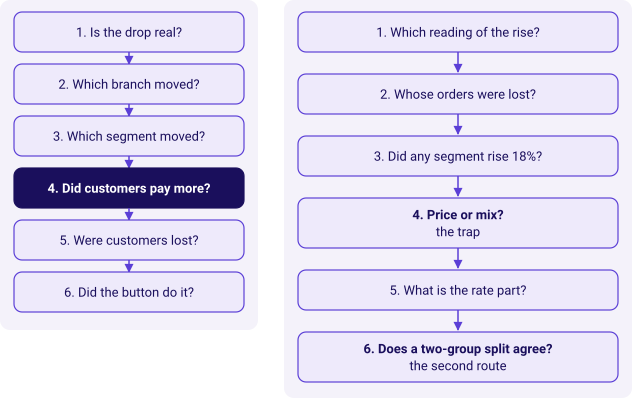

In [2]:
kit.side_by_side(
    kit.ladder(['Is the drop real?', 'Which branch moved?', 'Which segment moved?', 'Did customers pay more?', 'Were customers lost?', 'Did the button do it?'], lit=3, show=False),
    kit.vflow(['1. Which reading of the rise?', '2. Whose orders were lost?', '3. Did any segment rise 18%?', '4. Price or mix?\nthe trap', '5. What is the rate part?', '6. Does a two-group split agree?\nthe second route'], show=False),
)

## 1. Which of four readings can put rupees on "customers paid more" and on "the mix changed"?

| Option | How | What it can say |
|---|---|---|
| A. Read the blended change | Q2 revenue per order against Q1, all orders | The size of the rise, and nothing about why |
| B. Each segment's own revenue per order | `tree_for` per segment, Q1 against Q2 | Whether any segment's customers paid more, one segment at a time |
| C. Split the rise into mix and rate | Price Q2's order mix at Q1's segment rates; the rest is rate | Rupees of the rise from mix and from rate, adding to the whole |
| D. Each segment's median order | `describe` per segment | The typical order, which one lakh-sized order cannot move |

On this file each reading is sized by how much of the Rs 33,231 rise it can put rupees on, whether
one lakh-sized order can move it, and what it leaves open.

Option,Rupees of the rise it explains,Can one lakh-sized order move it?,What it leaves open
A. blended change,none: it is the rise,yes,why
B. per segment,none: a direction per segment,"yes, inside Business",how the segments add up
C. mix and rate,"all Rs 33,231, split","the rate part, yes","which prices moved, if any"
D. medians per segment,none: the typical order,no,rupees


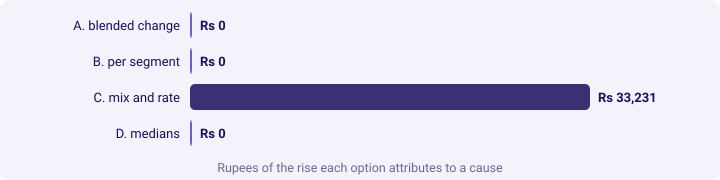

In [3]:
rise = all2["revenue_per_order"] - all1["revenue_per_order"]
share1 = {seg: q1[seg]["orders"] / all1["orders"] for seg in SEGMENTS}
share2 = {seg: q2[seg]["orders"] / all2["orders"] for seg in SEGMENTS}
at_q2_mix = sum(share2[seg] * q1[seg]["revenue_per_order"] for seg in SEGMENTS)
mix = at_q2_mix - all1["revenue_per_order"]
rate = all2["revenue_per_order"] - at_q2_mix
kit.table(["Option", "Rupees of the rise it explains", "Can one lakh-sized order move it?", "What it leaves open"],
          [("A. blended change", "none: it is the rise", "yes", "why"),
           ("B. per segment", "none: a direction per segment", "yes, inside Business", "how the segments add up"),
           ("C. mix and rate", f"all {kit.rupees(round(rise))}, split", "the rate part, yes", "which prices moved, if any"),
           ("D. medians per segment", "none: the typical order", "no", "rupees")],
          caption="Sizing four readings of one rise")
kit.bars([("A. blended change", 0), ("B. per segment", 0), ("C. mix and rate", round(rise)), ("D. medians", 0)],
         fmt=kit.rupees, lit=[2], title="Rupees of the rise each option attributes to a cause")
kit.check("option C's two parts add back to the whole rise", abs(mix + rate - rise) < 1e-6, kit.rupees(round(rise)))

**The best-fit call.** Option C, the split, built on option B's per-segment rates, because it is the
only reading that puts rupees on "customers paid more" and on "the mix changed" and makes them add to
the Rs 33,231 rise. **The fact that would change the call:** if the segments' orders were similar in
size, mix would barely move the blend and option B alone would do; if Marketing wanted to know which
products' prices moved, only order lines, which this file does not carry, would answer.

## 2. How many of the 28 lost orders were Retail-Plus?

**Predict before you run.** Of the 28 orders lost between the quarters, how many were Retail-Plus
orders? a) about 7, a quarter; b) about 14, half; c) 25; d) all 28.

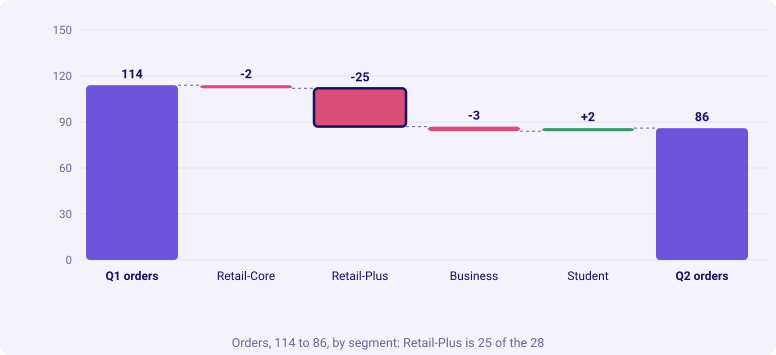

In [4]:
order_moves = {seg: q2[seg]["orders"] - q1[seg]["orders"] for seg in SEGMENTS}
kit.bridge(("Q1 orders", all1["orders"]), [(seg, order_moves[seg]) for seg in SEGMENTS],
           end_label="Q2 orders", lit=[1], fmt=lambda v: f"{v:,.0f}",
           title="Orders, 114 to 86, by segment: Retail-Plus is 25 of the 28")
kit.check("the orders bridge lands on 86", all1["orders"] + sum(order_moves.values()) == all2["orders"])
kit.check("Retail-Plus is 25 of the 28 lost orders", order_moves["Retail-Plus"] == -25, f'{order_moves["Retail-Plus"]}')

**What happened.** The answer is c. Retail-Plus lost 25 orders, Business 3 and Retail-Core 2, while
Student gained 2. The orders that vanished were small ones, about three thousand rupees each, which
already hints at why the average order grew.

## 3. Did any segment's own revenue per order rise 18 percent?

**Predict before you run.** Which segment's own revenue per order rose by about 18 percent? a)
Business; b) Retail-Plus; c) every segment; d) none of them.

Segment,Q1 revenue per order,Q2 revenue per order,Change
Retail-Core,"Rs 2,117","Rs 2,014",-4.9%
Retail-Plus,"Rs 2,815","Rs 3,012",+7.0%
Business,"Rs 10,38,559","Rs 10,90,674",+5.0%
Student,Rs 962,"Rs 1,104",+14.8%
"all orders, blended","Rs 1,84,211","Rs 2,17,442",+18.0%


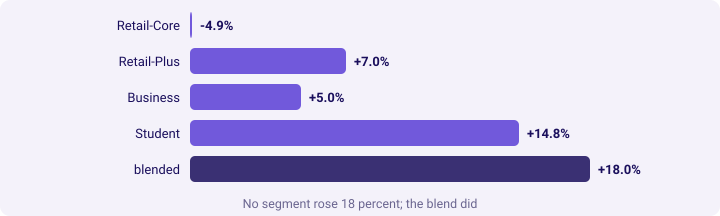

In [5]:
seg_rpo_change = {seg: (q2[seg]["revenue_per_order"] / q1[seg]["revenue_per_order"] - 1) * 100 for seg in SEGMENTS}
kit.table(["Segment", "Q1 revenue per order", "Q2 revenue per order", "Change"],
          [(seg, kit.rupees(round(q1[seg]["revenue_per_order"])), kit.rupees(round(q2[seg]["revenue_per_order"])),
            f"{seg_rpo_change[seg]:+.1f}%") for seg in SEGMENTS] +
          [("all orders, blended", kit.rupees(round(all1["revenue_per_order"])), kit.rupees(round(all2["revenue_per_order"])),
            f'{(all2["revenue_per_order"] / all1["revenue_per_order"] - 1) * 100:+.1f}%')],
          caption="Revenue per order inside each segment, and the blend")
kit.bars([(seg, round(seg_rpo_change[seg], 1)) for seg in SEGMENTS] + [("blended", 18.0)],
         fmt=lambda v: f"{v:+.1f}%", lit=[4], title="No segment rose 18 percent; the blend did")
kit.check("no segment's own revenue per order rose as far as 18 percent", max(seg_rpo_change.values()) < 18.0,
          f"largest {max(seg_rpo_change.values()):.1f}%")

**What happened.** The answer is d. Business rose 5.0 percent, Retail-Plus 7.0, Student 14.8, and
Retail-Core fell 4.9. The blend rose 18.0 percent while no segment rose that far, so the blend moved
because the mix of orders moved.

## 4. Did customers pay 18 percent more, or did the mix move the blend?

**The plausible wrong answer.** A hurried analyst reads the blended rise straight into the plan.

In [6]:
wrong_rise = (all2["revenue_per_order"] / all1["revenue_per_order"] - 1) * 100
kit.stats([(f"{wrong_rise:+.1f}%", "revenue per order, blended", "read as: customers pay 18 percent more"),
           (kit.rupees(round(rise)), "more per order", "read as: room for a price rise"),
           ("0", "segments that rose 18 percent", "the check")])
kit.check("the hurried figure is plus 18.0 percent", round(wrong_rise, 1) == 18.0)

**Why it is wrong.** Revenue per order is a blend. It rises whenever small orders fall away, even if
no customer pays a rupee more, and 25 small Retail-Plus orders fell away. Reading it as a price
signal would put a price rise on customers who never paid more, in the tier whose orders already
halved.

**The check.** Question 3's table already shows that no segment's own revenue per order rose 18
percent.

**The fix.** Option C prices Q2's order mix at Q1's revenue per order in each segment and calls what
is left the rate.

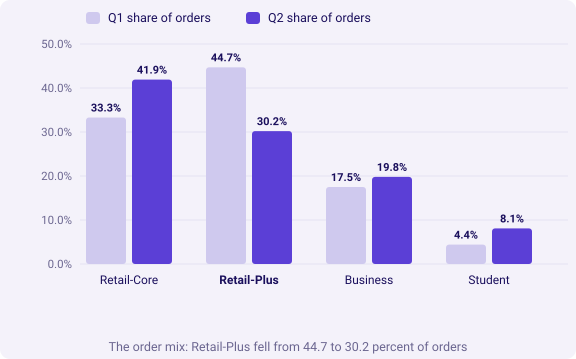

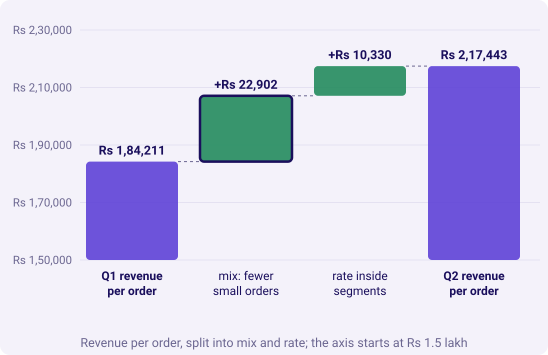

In [7]:
s1 = [round(share1[seg] * 100, 1) for seg in SEGMENTS]
s2 = [round(share2[seg] * 100, 1) for seg in SEGMENTS]
kit.columns(SEGMENTS, [("Q1 share of orders", s1), ("Q2 share of orders", s2)], fmt=lambda v: f"{v:.1f}%", lit=[1],
            title="The order mix: Retail-Plus fell from 44.7 to 30.2 percent of orders")
kit.bridge(("Q1 revenue per order", round(all1["revenue_per_order"])), [("mix: fewer small orders", round(mix)), ("rate inside segments", round(rate))],
           end_label="Q2 revenue per order", lit=[0], lo=150000, fmt=kit.rupees,
           title="Revenue per order, split into mix and rate; the axis starts at Rs 1.5 lakh")
kit.check("at Q2's mix and Q1's rates, revenue per order is Rs 2,07,112", round(at_q2_mix) == 207112, kit.rupees(round(at_q2_mix)))
kit.check("mix explains about 69 percent of the rise", round(mix / rise * 100) == 69, f"{mix / rise * 100:.1f}")

**What changed.** "Customers pay 18 percent more, raise prices" became "at Q2's mix and Q1's rates,
revenue per order would already have been Rs 2,07,112: the mix explains Rs 22,902 of the Rs 33,231
rise, about 69 percent, and the rate inside segments Rs 10,330", so the price rise has lost its
evidence.

## 5. What is the rate part made of?

The Rs 10,330 of rate is itself a blend of four segments' own changes, each weighted by its share of
Q2's orders.

**Predict before you run.** Which segment carries most of the rate part? a) Retail-Plus; b)
Retail-Core; c) Business; d) Student.

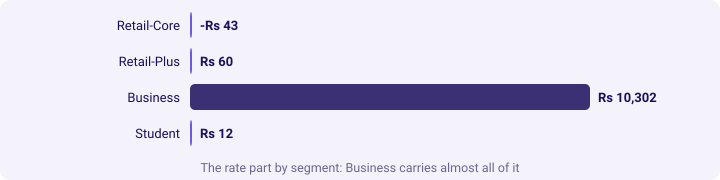

In [8]:
rate_parts = {seg: share2[seg] * (q2[seg]["revenue_per_order"] - q1[seg]["revenue_per_order"]) for seg in SEGMENTS}
kit.bars([(seg, round(rate_parts[seg])) for seg in SEGMENTS], fmt=kit.rupees, lit=[2],
         title="The rate part by segment: Business carries almost all of it")
kit.check("the rate parts add back to the rate", abs(sum(rate_parts.values()) - rate) < 1e-6, kit.rupees(round(rate)))
kit.check("Business carries more than nine tenths of the rate part", rate_parts["Business"] / rate > 0.9,
          f'{rate_parts["Business"] / rate * 100:.1f}%')

**What happened.** The answer is c. The rate part is almost all Business, whose 17 orders each grew
about Rs 52,000 on average, and one large order drives that, as chapter 3's range showed. The
consumer segments' own revenue per order moved by a few hundred rupees at most.

## 6. Does a back-of-envelope split, Business against everyone else, put the same share of the rise on the mix?

The split in question 4 priced four segments. An independent check, small enough for the back of an
envelope, treats Kalpa as two groups, Business and everyone else, and asks how far the blend moves
when only Business's share of orders moves: the change in that share times the gap between a
Business order and a consumer order, both at Q1's values. It uses no rate inside the consumer business, so if the four-segment split had mispriced a
consumer segment, the two routes would disagree.

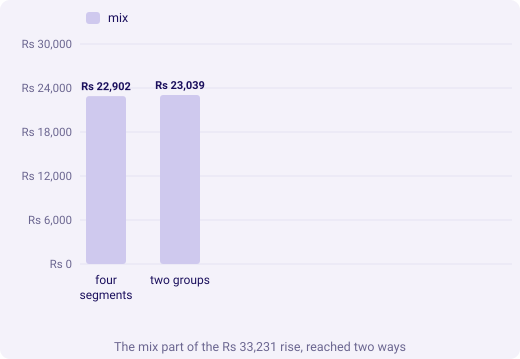

In [9]:
consumer_q1 = [o for o in by_quarter["Q1"] if o["segment"] != "Business"]
consumer_rpo_q1 = sum(o["amount"] for o in consumer_q1) / len(consumer_q1)
gap_q1 = q1["Business"]["revenue_per_order"] - consumer_rpo_q1
envelope = (share2["Business"] - share1["Business"]) * gap_q1
kit.stats([(f'{share1["Business"] * 100:.1f}% to {share2["Business"] * 100:.1f}%', "Business's share of orders", "Q1 to Q2"),
           (kit.rupees(round(gap_q1)), "a Business order less a consumer order", "both at Q1's values"),
           (kit.rupees(round(envelope)), "the mix, from two groups", f"four segments gave {kit.rupees(round(mix))}")])
kit.columns(["four segments", "two groups"], [("mix", [round(mix), round(envelope)])], fmt=kit.rupees, width=520,
            title="The mix part of the Rs 33,231 rise, reached two ways")
kit.check("the two routes agree within 2 percent", abs(envelope - mix) / mix < 0.02, f"{envelope:.0f} and {mix:.0f}")
kit.check("both routes put more than two thirds of the rise on the mix", mix / rise > 2 / 3 and envelope / rise > 2 / 3,
          f"{mix / rise * 100:.1f} and {envelope / rise * 100:.1f}")

The two routes agree: two groups put Rs 23,039 on the mix, 69.3 percent of the rise, against
Rs 22,902 and 68.9 percent from four segments.

**When to switch.** Report the four-segment split, since it names each segment's part. The envelope
is the check a senior runs in a meeting with no laptop, and it stops agreeing when the consumer
segments' own shares move a lot against each other, since it cannot see inside them.

> **Kavya's review.** "Marketing looked at a blend and saw a price signal. You opened the blend and
> found 25 small orders missing. Say it that way to Meera: no consumer segment paid meaningfully more,
> Business's share of orders rose from 17.5 to 19.8 percent as the small member orders left, and they
> left from the tier we are about to ask about."

### In the interview: did prices go up when revenue per order rose, and when does a mix split matter?

The tags mark how often a question comes up: [S] a staple asked everywhere, [F] frequent in GCC and product screens, [SV] a service-major screen opener, [D] a differentiator.

**[F] Revenue per order rose 18 percent while revenue fell; did prices go up?** "Prices may not
have moved at all, and on Kalpa's quarters they mostly did not. Revenue per order is a blend across
segments whose orders differ in size, so it rises whenever the small orders fall away. I split the change into mix and rate: price the later
period's mix at the earlier period's segment rates. On Kalpa's quarters mix explains Rs 22,902 of the
Rs 33,231 rise, about 69 percent, because small Retail-Plus orders disappeared, and Business carries
almost all of the rest. Then I check prices directly if the question matters." The interviewer is
listening for mix, the split, and a number for each part.

**The design question. When does a mix split matter, and when is a per-segment table enough?** "It
matters when the segments' rates differ a lot and their shares moved, since then the blend can move
with no segment moving; Kalpa's orders differ several hundredfold between Business and consumers, so it
matters here. When the segments look alike, or their shares held, the per-segment table says it all.
And I report the order of the split, since the joint part moves with it." The interviewer is
listening for the two conditions and the order.

### Depth: could Retail-Plus's own 7.0 percent rise be a mix as well?

Retail-Plus's own revenue per order rose 7.0 percent. That can be a mix as well: if the members who
place small orders are the ones who slowed, the tier's average order grows with no member paying
more. Try it: split the tier's rise by channel, the way this chapter split the company's by segment,
and say how much of the 7.0 percent is mix.

References for the chapter:

- Swiggy, Q2 FY2026 shareholder letter: https://www.swiggy.com/corporate/wp-content/uploads/2025/10/Q2-FY2026-Shareholder-letter.pdf (verified 30 Sep 2026)
- Khan Academy, summarizing quantitative data: https://www.khanacademy.org/math/statistics-probability/summarizing-quantitative-data (verified 29 Sep 2026)

## So, did customers pay more?

1. Of the four readings, only the split into mix and rate, built on each segment's own revenue per order, puts rupees on both causes, and its two parts add to the Rs 33,231 rise.
2. Retail-Plus was 25 of the 28 lost orders, Business 3 and Retail-Core 2, while Student gained 2; the lost orders were about three thousand rupees each.
3. No segment's own revenue per order rose 18 percent: Business rose 5.0 percent, Retail-Plus 7.0, Student 14.8, and Retail-Core fell 4.9.
4. Mostly the mix moved the blend: at Q2's mix and Q1's rates revenue per order would already be Rs 2,07,112, so the mix is Rs 22,902 of the Rs 33,231 rise, about 69 percent, and the rate Rs 10,330.
5. The rate part is almost all Business, whose 17 orders each grew about Rs 52,000 on average, one large order driving it; the consumer segments' own rates moved a few hundred rupees at most.
6. A back-of-envelope split, Business against everyone else, puts the same share of the rise on the mix: Rs 23,039, 69.3 percent, against 68.9 percent from four segments.

No. The 18 percent is no price signal: about 69 percent of the rise is mix, the small member orders
that left, and most of the rest is Business's lakh-sized orders.

In [10]:
kit.check_summary()
print("Next, chapter 5. Marketing says the flat count hides customers lost and replaced: were any lost, "
      "who slowed instead, and which segment fell most?")

Next, chapter 5. Marketing says the flat count hides customers lost and replaced: were any lost, who slowed instead, and which segment fell most?
